<a href="https://colab.research.google.com/github/chervov/ProteinModelling1/blob/main/JAK1_centroid_distances.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What is about ?

Computes the differences between centroids coordiantes of the JH2 and JH1 domains for JAK1 model. It can be used as a proxy for the open-closedness criteria.



# Alfafold model only

In [1]:
%pip install -q requests numpy pandas

from pathlib import Path
import requests
import numpy as np
import pandas as pd

UNIPROT_ID = "P23458"  # Human JAK1
CHAIN_ID = "A"


def get_json(url):
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    return response.json()


# ------------------------------------------------------------
# 1. Retrieve domain boundaries directly from UniProt
# ------------------------------------------------------------
uniprot = get_json(
    f"https://rest.uniprot.org/uniprotkb/{UNIPROT_ID}.json"
)

# UniProt calls JH2 "Protein kinase 1" and JH1 "Protein kinase 2".
domain_names = {
    "Protein kinase 1": "JH2",
    "Protein kinase 2": "JH1",
}

domains = {}

for feature in uniprot.get("features", []):
    if feature["type"] != "Domain":
        continue

    description = feature.get("description", "")
    if description in domain_names:
        name = domain_names[description]
        start = int(feature["location"]["start"]["value"])
        end = int(feature["location"]["end"]["value"])
        domains[name] = [[start, end]]

if set(domains) != {"JH1", "JH2"}:
    raise ValueError(f"Could not identify both kinase domains: {domains}")

print(f"Human JAK1: {UNIPROT_ID}")
print(f"UniProt sequence length: {uniprot['sequence']['length']}")
for name in ("JH2", "JH1"):
    start, end = domains[name][0]
    print(f"{name}: residues {start}–{end}, inclusive")


# ------------------------------------------------------------
# 2. Download the AlphaFold database model
#    Use its API so the model version is not hard-coded.
# ------------------------------------------------------------
predictions = get_json(
    f"https://alphafold.ebi.ac.uk/api/prediction/{UNIPROT_ID}"
)

if not predictions:
    raise ValueError("No AlphaFold model found.")

sequence_length = uniprot["sequence"]["length"]

full_length_models = [
    prediction
    for prediction in predictions
    if int(prediction.get("uniprotStart", -1)) == 1
    and int(prediction.get("uniprotEnd", -1)) == sequence_length
    and prediction.get("pdbUrl")
]

if not full_length_models:
    raise ValueError(
        "No full-length model found; fragment numbering needs explicit mapping."
    )

prediction = full_length_models[0]
pdb_url = prediction["pdbUrl"]
pdb_path = Path("/content/AF_JAK1.pdb")

response = requests.get(pdb_url, timeout=120)
response.raise_for_status()
pdb_path.write_text(response.text)

print(f"\nDownloaded: {pdb_url}")
print(f"Saved as: {pdb_path}")


# ------------------------------------------------------------
# 3. Read Cα coordinates — same parsing logic as Orianne's code
# ------------------------------------------------------------
def parse_pdb_ca_coords(pdb_file, chain_id=None):
    coords = {}

    with open(pdb_file) as f:
        for line in f:
            if not line.startswith("ATOM"):
                continue
            if line[12:16].strip() != "CA":
                continue
            if chain_id is not None and line[21].strip() != chain_id:
                continue

            try:
                residue_number = int(line[22:26].strip())
                xyz = np.array(
                    [
                        float(line[30:38]),
                        float(line[38:46]),
                        float(line[46:54]),
                    ],
                    dtype=np.float64,
                )
            except ValueError:
                continue

            coords[residue_number] = xyz

    return coords


# ------------------------------------------------------------
# 4. Compute centroids — same averaging logic as Orianne's code
# ------------------------------------------------------------
def centroid_for_ranges(coords, ranges):
    points = []

    for start, end in ranges:
        for residue_number in range(start, end + 1):
            if residue_number in coords:
                points.append(coords[residue_number])

    if not points:
        raise ValueError(f"No Cα atoms found for ranges {ranges}")

    return np.mean(np.stack(points, axis=0), axis=0)


coords = parse_pdb_ca_coords(pdb_path, chain_id=CHAIN_ID)

if not coords:
    raise ValueError(f"No Cα atoms found in chain {CHAIN_ID!r}")

# Check coverage so missing residues do not silently change the centroids.
for name, ranges in domains.items():
    missing = [
        residue_number
        for start, end in ranges
        for residue_number in range(start, end + 1)
        if residue_number not in coords
    ]
    if missing:
        raise ValueError(f"{name}: missing Cα atoms for residues {missing}")

centroid_jh2 = centroid_for_ranges(coords, domains["JH2"])
centroid_jh1 = centroid_for_ranges(coords, domains["JH1"])

distance = float(np.linalg.norm(centroid_jh1 - centroid_jh2))

rows = []
for name, centroid in (("JH2", centroid_jh2), ("JH1", centroid_jh1)):
    start, end = domains[name][0]
    rows.append({
        "Domain": name,
        "Start": start,
        "End": end,
        "CA_count": end - start + 1,
        "Centroid_X": centroid[0],
        "Centroid_Y": centroid[1],
        "Centroid_Z": centroid[2],
    })

print("\nDomain centroids (Å):")
display(pd.DataFrame(rows).set_index("Domain").round(3))

print(f"\nJH2–JH1 centroid distance: {distance:.3f} Å")

Human JAK1: P23458
UniProt sequence length: 1154
JH2: residues 583–855, inclusive
JH1: residues 875–1153, inclusive

Downloaded: https://alphafold.ebi.ac.uk/files/AF-P23458-F1-model_v6.pdb
Saved as: /content/AF_JAK1.pdb

Domain centroids (Å):


,Start,End,CA_count,Centroid_X,Centroid_Y,Centroid_Z
Domain,,,,,,
JH2,583,855,273,9.198,3.569,-5.194
JH1,875,1153,279,47.461,5.966,-31.076



JH2–JH1 centroid distance: 46.256 Å


# Four models

In [2]:
%pip install -q biopython requests numpy pandas

import io
from pathlib import Path

import requests
import numpy as np
import pandas as pd
from Bio.PDB import PDBParser
from Bio.Align import PairwiseAligner
from Bio.SeqUtils import seq1
from IPython.display import display

UNIPROT_ID = "P23458"
OUTPUT_DIR = Path("/content/JAK1_centroids")
OUTPUT_DIR.mkdir(exist_ok=True)


def get_json(url):
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    return response.json()


# ------------------------------------------------------------
# 1. UniProt reference sequence and domain boundaries
# ------------------------------------------------------------
uniprot = get_json(
    f"https://rest.uniprot.org/uniprotkb/{UNIPROT_ID}.json"
)
reference_sequence = uniprot["sequence"]["value"]

domain_names = {
    "Protein kinase 1": "JH2",
    "Protein kinase 2": "JH1",
}
domains = {}

for feature in uniprot.get("features", []):
    if feature["type"] == "Domain":
        description = feature.get("description", "")
        if description in domain_names:
            domains[domain_names[description]] = (
                int(feature["location"]["start"]["value"]),
                int(feature["location"]["end"]["value"]),
            )

if set(domains) != {"JH2", "JH1"}:
    raise ValueError(f"Could not identify both domains: {domains}")

print("UniProt domain boundaries (inclusive):")
for name in ("JH2", "JH1"):
    start, end = domains[name]
    print(f"  {name}: {start}–{end}, {end - start + 1} residues")


# ------------------------------------------------------------
# 2. Resolve AlphaFold download URL
# ------------------------------------------------------------
predictions = get_json(
    f"https://alphafold.ebi.ac.uk/api/prediction/{UNIPROT_ID}"
)

full_length_models = [
    p for p in predictions
    if int(p.get("uniprotStart", -1)) == 1
    and int(p.get("uniprotEnd", -1)) == len(reference_sequence)
    and p.get("pdbUrl")
]

if not full_length_models:
    raise ValueError("No full-length AlphaFold model found.")

base_url = (
    "https://raw.githubusercontent.com/"
    "chervov/ProteinModelling1/main/JAK1/"
)

MODEL_URLS = {
    "AlphaFold": full_length_models[0]["pdbUrl"],
    "Jeanpierre closed": (
        base_url + "Jeanpierre2025_Closed_WT_JAK1_best_model.pdb"
    ),
    "Jeanpierre open": (
        base_url + "Jeanpierre2025_Open_WT_JAK1_best_model.pdb"
    ),
    "Shan 2014": (
        base_url
        + "Shan2014_NIHMS704086-supplement-PDB_coordinates_for_JAK1_model.pdb"
    ),
}


# ------------------------------------------------------------
# 3. Sequence alignment
#    Reference = full-length UniProt sequence.
#    Query = modeled residues in a PDB chain.
#    Unmodeled reference termini are allowed without penalty.
# ------------------------------------------------------------
aligner = PairwiseAligner()
aligner.mode = "global"
aligner.match_score = 2
aligner.mismatch_score = -1
aligner.open_gap_score = -8
aligner.extend_gap_score = -0.5
aligner.query_left_gap_score = 0
aligner.query_right_gap_score = 0


def map_chain_to_uniprot(chain):
    residues = [
        residue for residue in chain
        if residue.id[0] == " " and "CA" in residue
    ]

    if not residues:
        return None

    sequence = "".join(
        seq1(residue.resname, undef_code="X")
        for residue in residues
    )

    alignment = aligner.align(reference_sequence, sequence)[0]

    # UniProt position -> modeled residue object
    mapping = {}
    matches = 0
    aligned_count = 0

    for reference_block, query_block in zip(
        alignment.aligned[0], alignment.aligned[1]
    ):
        reference_start, reference_end = map(int, reference_block)
        query_start, query_end = map(int, query_block)

        for reference_index, query_index in zip(
            range(reference_start, reference_end),
            range(query_start, query_end),
        ):
            mapping[reference_index + 1] = residues[query_index]
            matches += (
                reference_sequence[reference_index] == sequence[query_index]
            )
            aligned_count += 1

    identity = matches / aligned_count if aligned_count else 0.0

    return {
        "chain": chain.id,
        "mapping": mapping,
        "identity": identity,
        "matches": matches,
        "modeled_CA": len(residues),
    }


def load_model(pdb_text):
    structure = PDBParser(QUIET=True).get_structure(
        "JAK1", io.StringIO(pdb_text)
    )
    first_model = next(structure.get_models())

    candidates = [
        result
        for chain in first_model
        if (result := map_chain_to_uniprot(chain)) is not None
    ]

    if not candidates:
        raise ValueError("No protein chains with Cα atoms found.")

    # Select the chain with the most matching JAK1 residues.
    best = max(candidates, key=lambda result: result["matches"])

    if best["identity"] < 0.90:
        raise ValueError(
            f"Low sequence identity to JAK1: {best['identity']:.1%}"
        )

    return best


def centroid(mapping, positions):
    coordinates = np.array(
        [mapping[position]["CA"].coord for position in positions],
        dtype=np.float64,
    )
    if len(coordinates) == 0:
        raise ValueError("No coordinates available for centroid.")
    return coordinates.mean(axis=0)


# ------------------------------------------------------------
# 4. Download and map all four models
# ------------------------------------------------------------
models = {}

for name, url in MODEL_URLS.items():
    response = requests.get(url, timeout=120)
    response.raise_for_status()

    filename = name.replace(" ", "_") + ".pdb"
    (OUTPUT_DIR / filename).write_text(response.text)

    models[name] = load_model(response.text)

    model = models[name]
    print(
        f"\n{name}: chain {model['chain']!r}, "
        f"{model['modeled_CA']} modeled Cα atoms, "
        f"sequence identity {model['identity']:.2%}"
    )


# ------------------------------------------------------------
# 5. Compute centroid vectors and distances
# ------------------------------------------------------------
def make_results(use_common_residues=False):
    positions_by_domain = {}

    for domain, (start, end) in domains.items():
        positions = set(range(start, end + 1))

        if use_common_residues:
            for model in models.values():
                positions &= set(model["mapping"])

        positions_by_domain[domain] = positions

    rows = []

    for name, model in models.items():
        mapping = model["mapping"]
        selected = {}

        for domain in ("JH2", "JH1"):
            selected[domain] = sorted(
                positions_by_domain[domain] & set(mapping)
            )

        c_jh2 = centroid(mapping, selected["JH2"])
        c_jh1 = centroid(mapping, selected["JH1"])

        # Difference vector points from JH2 centroid toward JH1.
        delta = c_jh1 - c_jh2
        distance = float(np.linalg.norm(delta))

        rows.append({
            "Model": name,
            "Chain": model["chain"],
            "JH2_CA_count": len(selected["JH2"]),
            "JH1_CA_count": len(selected["JH1"]),
            "JH2_x": c_jh2[0],
            "JH2_y": c_jh2[1],
            "JH2_z": c_jh2[2],
            "JH1_x": c_jh1[0],
            "JH1_y": c_jh1[1],
            "JH1_z": c_jh1[2],
            "Delta_x": delta[0],
            "Delta_y": delta[1],
            "Delta_z": delta[2],
            "Distance_A": distance,
        })

    return pd.DataFrame(rows).set_index("Model")


results = make_results(use_common_residues=False)

print("\nUsing all available Cα atoms within each UniProt domain:")
display(results.round(3))

# A second comparison uses exactly the same residue positions
# in every model, avoiding differences caused by missing residues.
common_results = make_results(use_common_residues=True)

print("\nUsing only domain residues present in ALL FOUR models:")
display(
    common_results[
        ["JH2_CA_count", "JH1_CA_count", "Distance_A"]
    ].round(3)
)

print("\nCentroid distances using common residues:")
for name, row in common_results.iterrows():
    print(f"  {name:20s}: {row['Distance_A']:.3f} Å")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.7 MB/s eta 0:00:00
UniProt domain boundaries (inclusive):
  JH2: 583–855, 273 residues
  JH1: 875–1153, 279 residues


/usr/local/lib/python3.13/dist-packages/Bio/Align/__init__.py:4412: BiopythonDeprecationWarning: The attribute 'query_left_gap_score' was renamed to 'left_deletion_score'. This was done to be consistent with the
AlignmentCounts object returned by the .counts method of an Alignment object.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/Bio/Align/__init__.py:4412: BiopythonDeprecationWarning: The attribute 'query_right_gap_score' was renamed to 'right_deletion_score'. This was done to be consistent with the
AlignmentCounts object returned by the .counts method of an Alignment object.
  warnings.warn(



AlphaFold: chain 'A', 1154 modeled Cα atoms, sequence identity 100.00%

Jeanpierre closed: chain 'A', 1154 modeled Cα atoms, sequence identity 100.00%

Jeanpierre open: chain 'A', 1154 modeled Cα atoms, sequence identity 100.00%

Shan 2014: chain 'X', 592 modeled Cα atoms, sequence identity 98.48%

Using all available Cα atoms within each UniProt domain:


,Chain,JH2_CA_count,JH1_CA_count,JH2_x,JH2_y,JH2_z,JH1_x,JH1_y,JH1_z,Delta_x,Delta_y,Delta_z,Distance_A
Model,,,,,,,,,,,,,
AlphaFold,A,273,279,9.198,3.569,-5.194,47.461,5.966,-31.076,38.262,2.397,-25.882,46.256
Jeanpierre closed,A,273,279,25.192,-2.274,-1.038,-3.155,-2.279,-28.590,-28.347,-0.005,-27.552,39.531
Jeanpierre open,A,273,279,5.224,-3.568,-7.831,40.831,-19.039,-32.597,35.607,-15.471,-24.766,46.050
Shan 2014,X,273,279,0.242,-20.562,-0.565,-2.458,17.353,0.784,-2.700,37.914,1.349,38.034



Using only domain residues present in ALL FOUR models:


,JH2_CA_count,JH1_CA_count,Distance_A
Model,,,
AlphaFold,273,279,46.256
Jeanpierre closed,273,279,39.531
Jeanpierre open,273,279,46.050
Shan 2014,273,279,38.034



Centroid distances using common residues:
  AlphaFold           : 46.256 Å
  Jeanpierre closed   : 39.531 Å
  Jeanpierre open     : 46.050 Å
  Shan 2014           : 38.034 Å


# Plots

In [3]:
%pip install -q py3Dmol

import py3Dmol

# UniProt domain boundaries, retrieved from the existing UniProt data.
DOMAIN_COLORS = {
    "FERM": "#3498db",
    "SH2": "#2ecc71",
    "Protein kinase 1": "#f39c12",
    "Protein kinase 2": "#9b59b6",
}

DOMAIN_LABELS = {
    "FERM": "FERM",
    "SH2": "SH2",
    "Protein kinase 1": "JH2 pseudokinase",
    "Protein kinase 2": "JH1 kinase",
}

plot_domains = []

for feature in uniprot.get("features", []):
    description = feature.get("description", "")
    if feature["type"] == "Domain" and description in DOMAIN_COLORS:
        plot_domains.append({
            "name": DOMAIN_LABELS[description],
            "start": int(feature["location"]["start"]["value"]),
            "end": int(feature["location"]["end"]["value"]),
            "color": DOMAIN_COLORS[description],
        })


def plot_model_by_domains(name, width=900, height=550):
    model = models[name]
    mapping = model["mapping"]
    chain_id = model["chain"]

    pdb_path = OUTPUT_DIR / (name.replace(" ", "_") + ".pdb")
    pdb_text = pdb_path.read_text()

    view = py3Dmol.view(width=width, height=height)
    view.addModel(pdb_text, "pdb")

    # Display only the selected JAK1 chain.
    view.setStyle({}, {})
    view.setStyle(
        {"chain": chain_id},
        {"cartoon": {"color": "#bdbdbd"}},
    )

    present_domains = []

    for domain in plot_domains:
        positions = [
            position
            for position in range(domain["start"], domain["end"] + 1)
            if position in mapping
        ]

        # Shan's fragment does not contain FERM or SH2.
        if not positions:
            continue

        # Translate UniProt coordinates into actual PDB residue identifiers.
        pdb_residue_ids = [
            f"{mapping[position].id[1]}{mapping[position].id[2].strip()}"
            for position in positions
        ]

        view.setStyle(
            {"chain": chain_id, "resi": pdb_residue_ids},
            {"cartoon": {"color": domain["color"]}},
        )

        center = centroid(mapping, positions)

        view.addLabel(
            domain["name"],
            {
                "position": {
                    "x": float(center[0]),
                    "y": float(center[1]),
                    "z": float(center[2]),
                },
                "fontSize": 16,
                "fontColor": domain["color"],
                "backgroundColor": "white",
                "backgroundOpacity": 0.85,
                "borderColor": domain["color"],
                "borderThickness": 1,
                "inFront": True,
            },
        )

        present_domains.append(
            f"{domain['name']} ({len(positions)} Cα atoms)"
        )

    print(f"\n{name}")
    print("Domains present: " + ", ".join(present_domains))

    view.setBackgroundColor("white")
    view.zoomTo({"chain": chain_id})
    view.show()

    return view


# Display all four models.
domain_views = {
    name: plot_model_by_domains(name)
    for name in MODEL_URLS
}


AlphaFold
Domains present: FERM (387 Cα atoms), SH2 (106 Cα atoms), JH2 pseudokinase (273 Cα atoms), JH1 kinase (279 Cα atoms)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


Jeanpierre closed
Domains present: FERM (387 Cα atoms), SH2 (106 Cα atoms), JH2 pseudokinase (273 Cα atoms), JH1 kinase (279 Cα atoms)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


Jeanpierre open
Domains present: FERM (387 Cα atoms), SH2 (106 Cα atoms), JH2 pseudokinase (273 Cα atoms), JH1 kinase (279 Cα atoms)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


Shan 2014
Domains present: JH2 pseudokinase (273 Cα atoms), JH1 kinase (279 Cα atoms)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

/content/JAK1_centroids/AlphaFold_domains.png


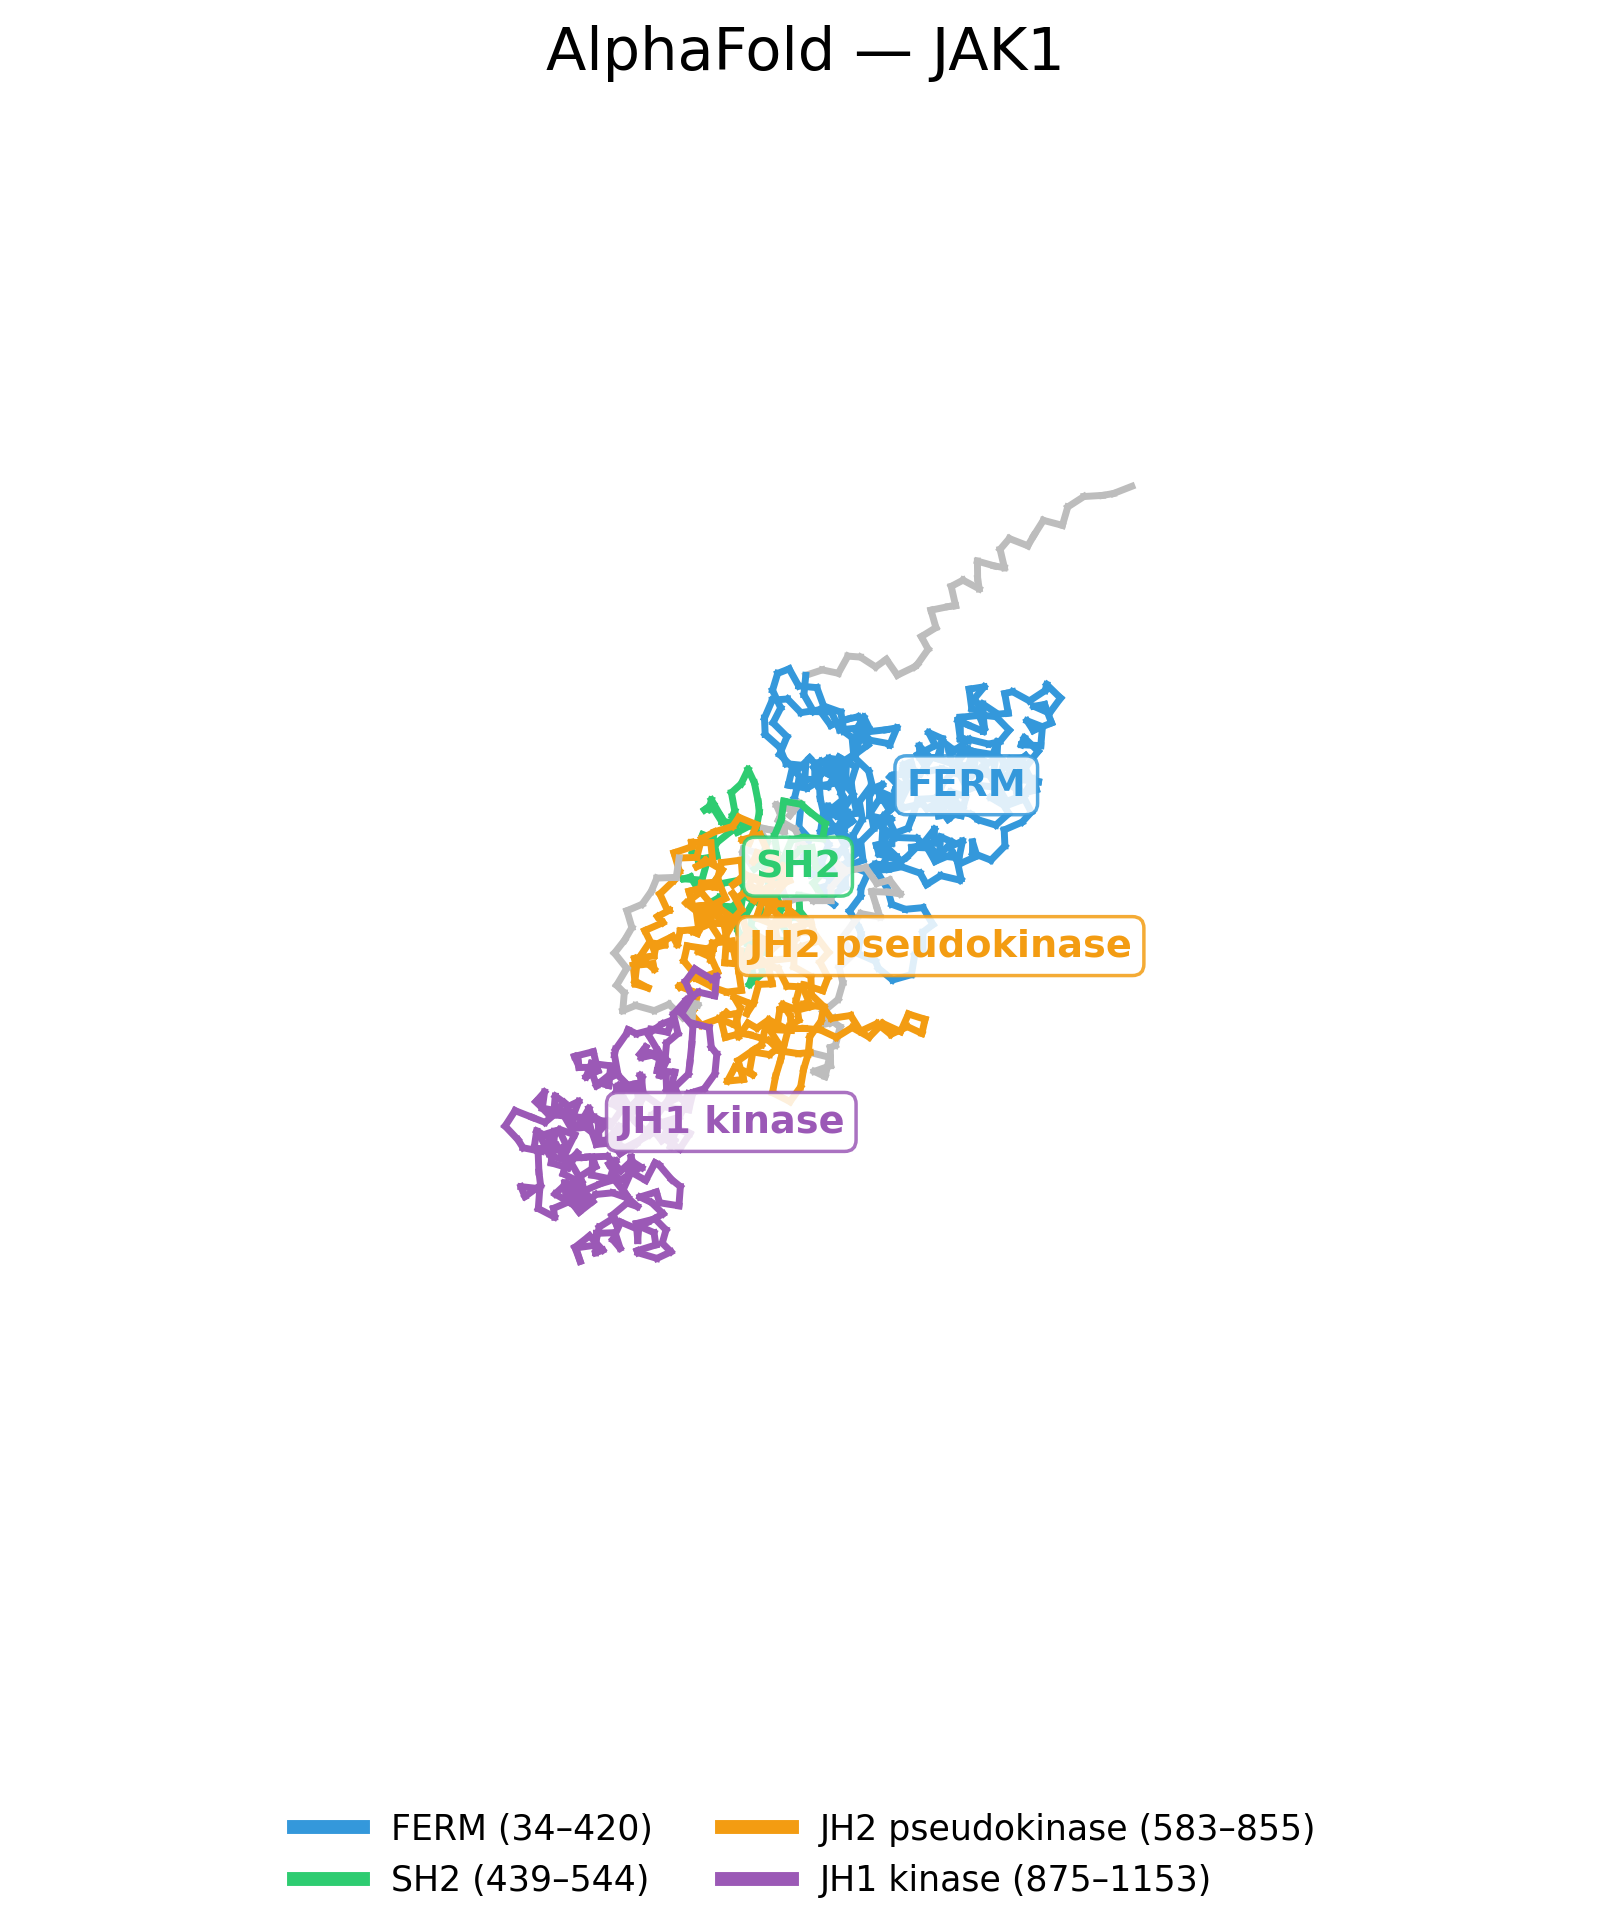

/content/JAK1_centroids/Jeanpierre_closed_domains.png


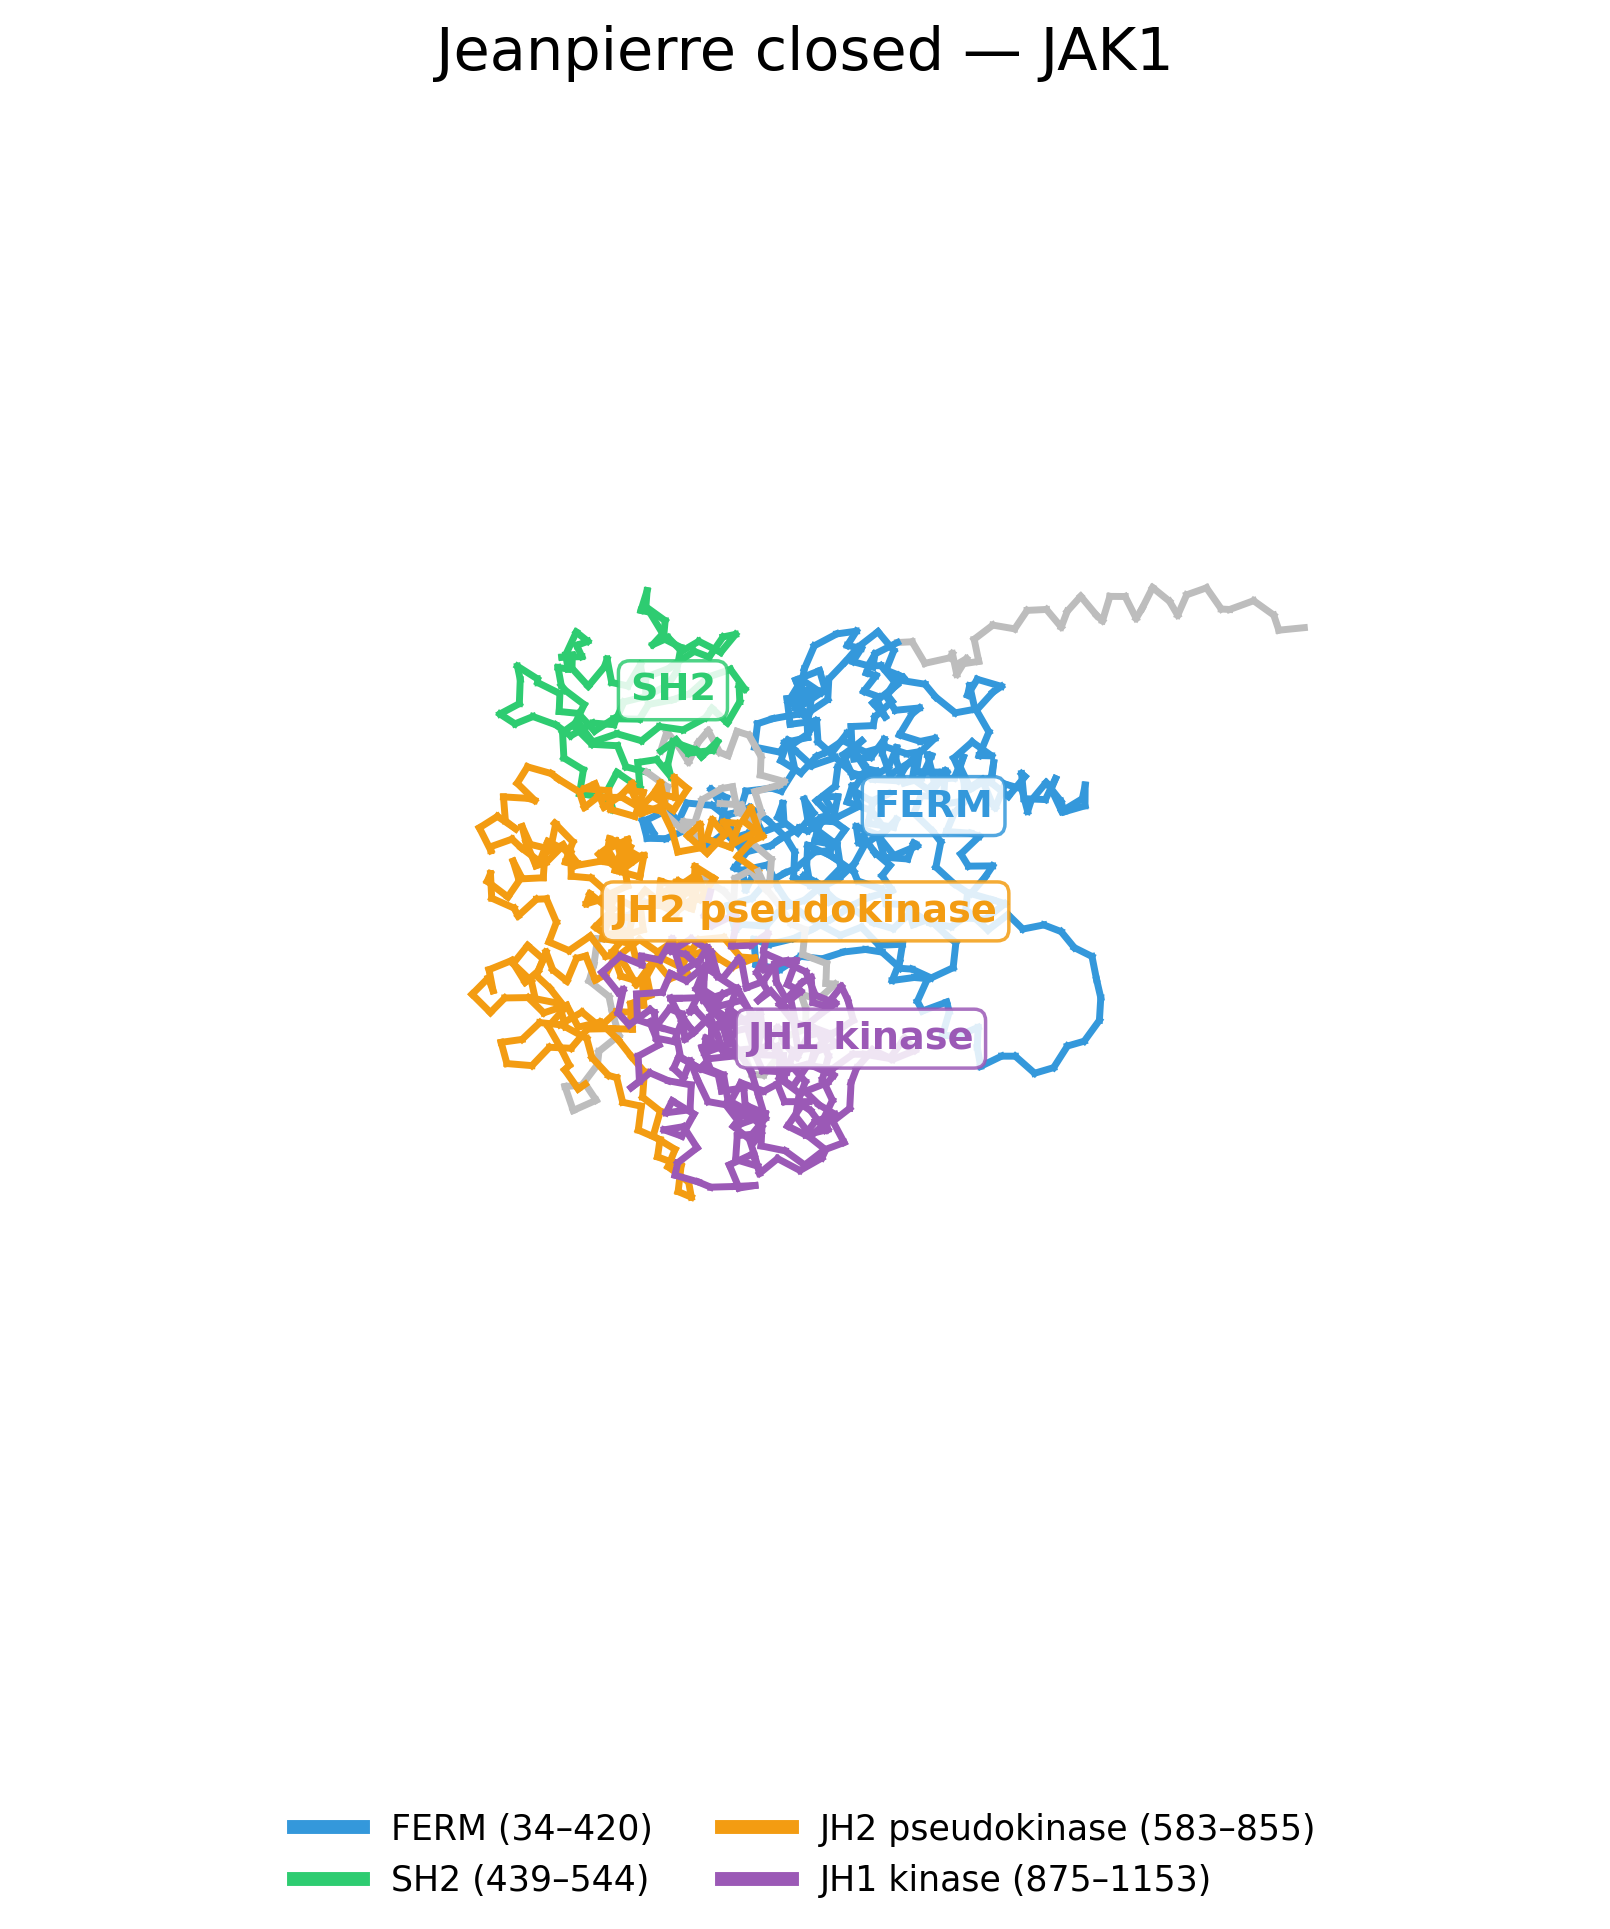

/content/JAK1_centroids/Jeanpierre_open_domains.png


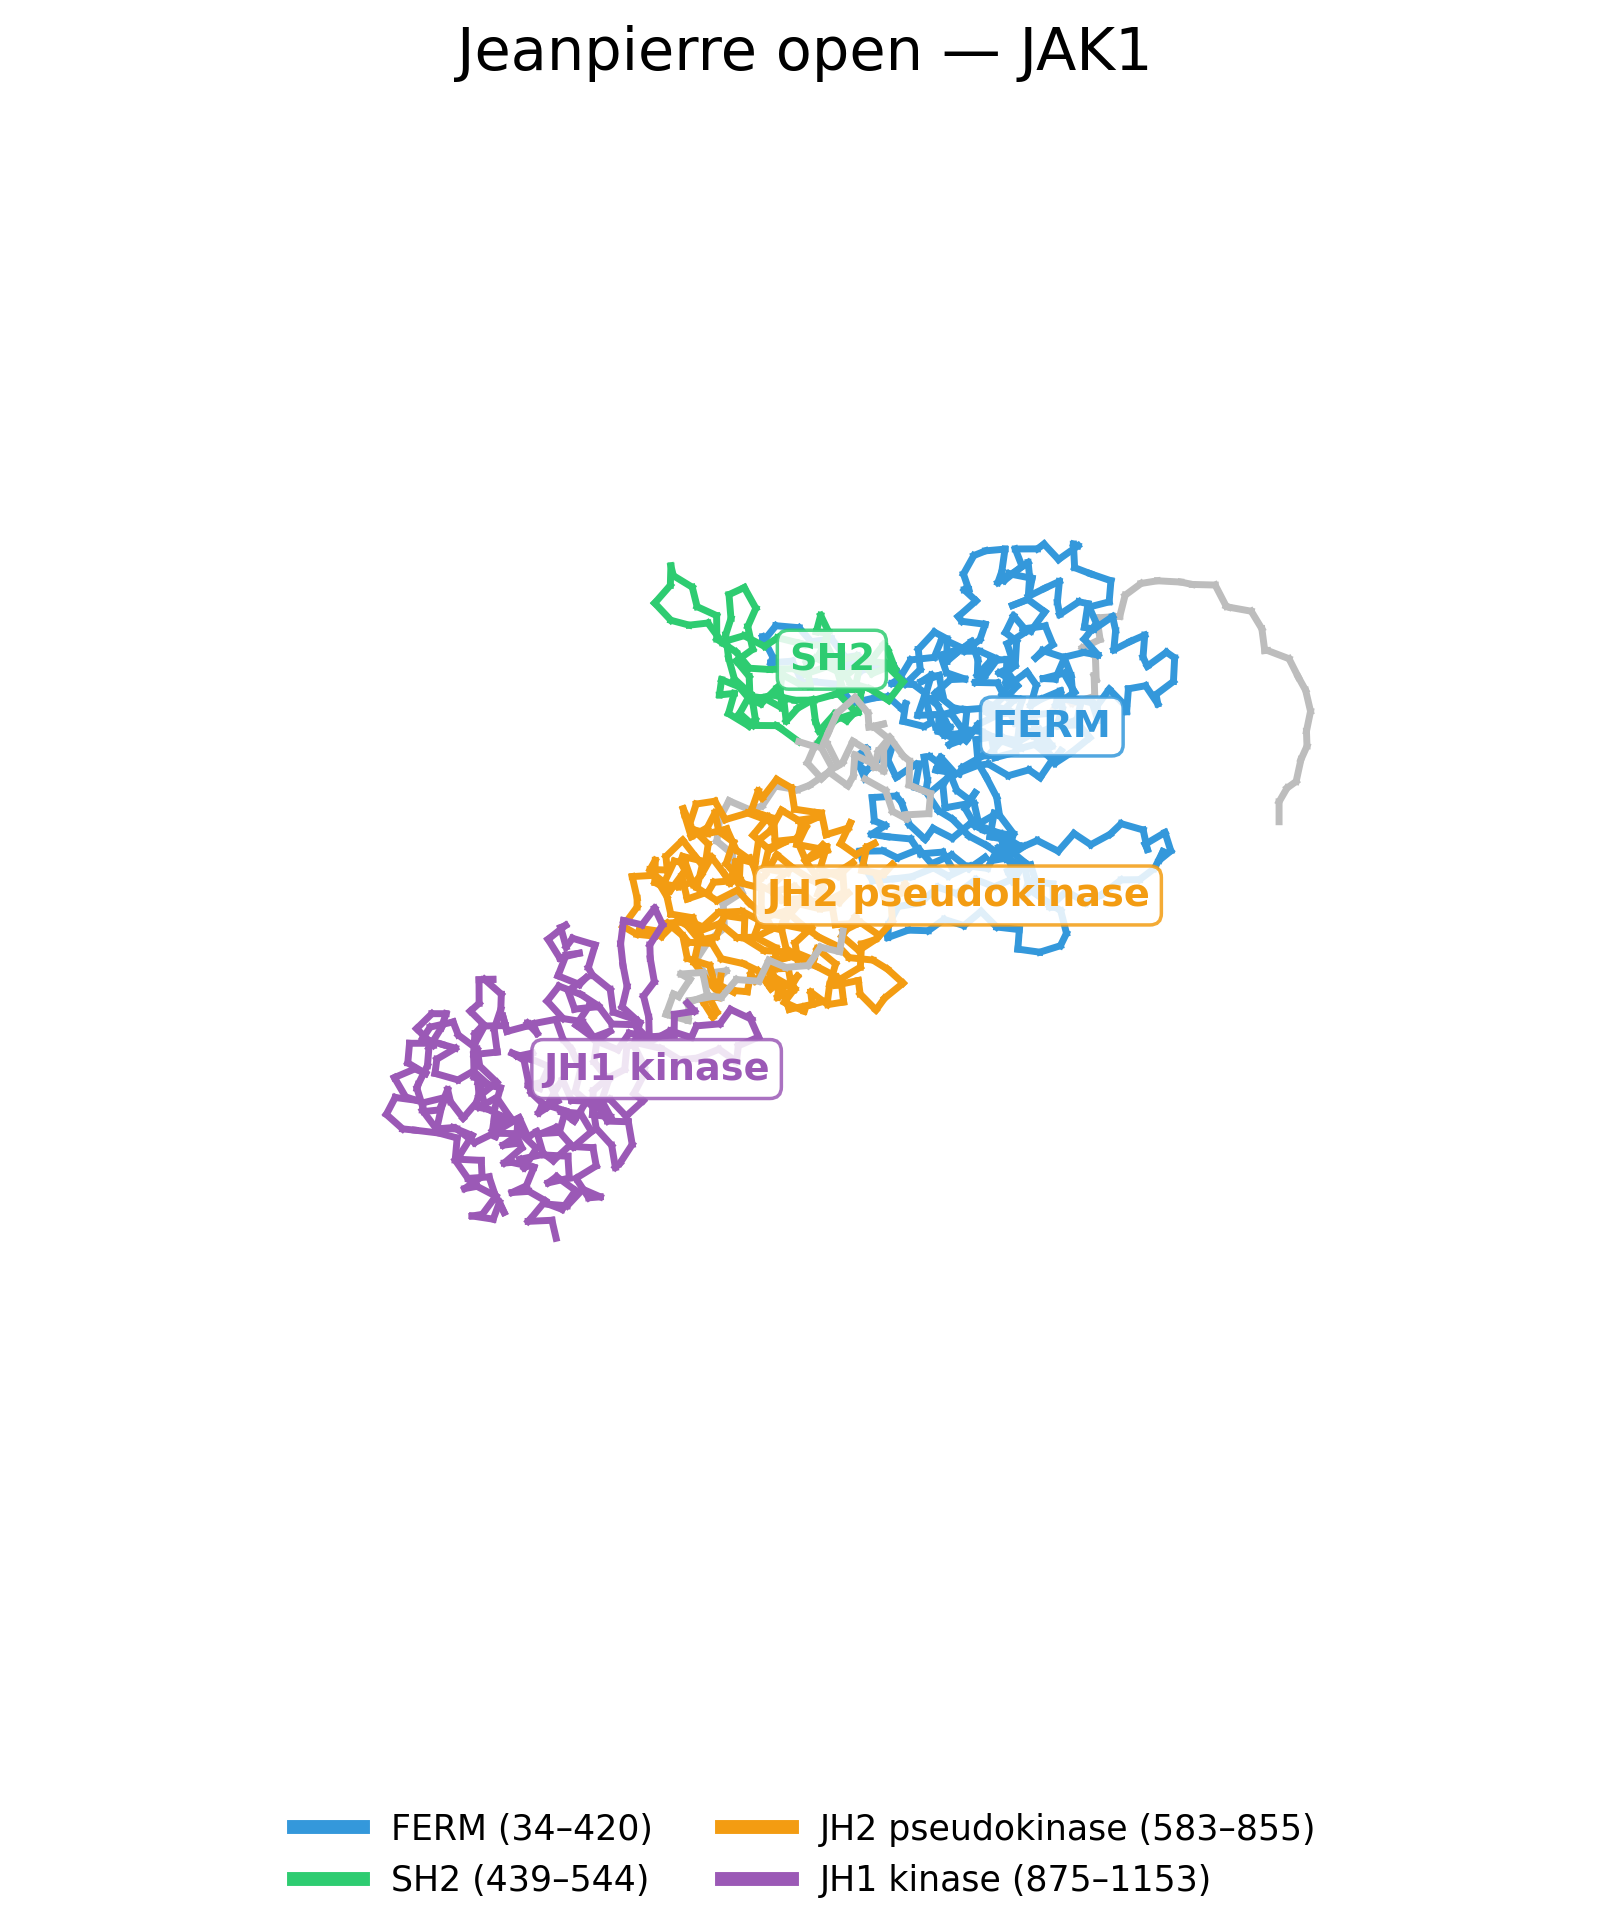

/content/JAK1_centroids/Shan_2014_domains.png


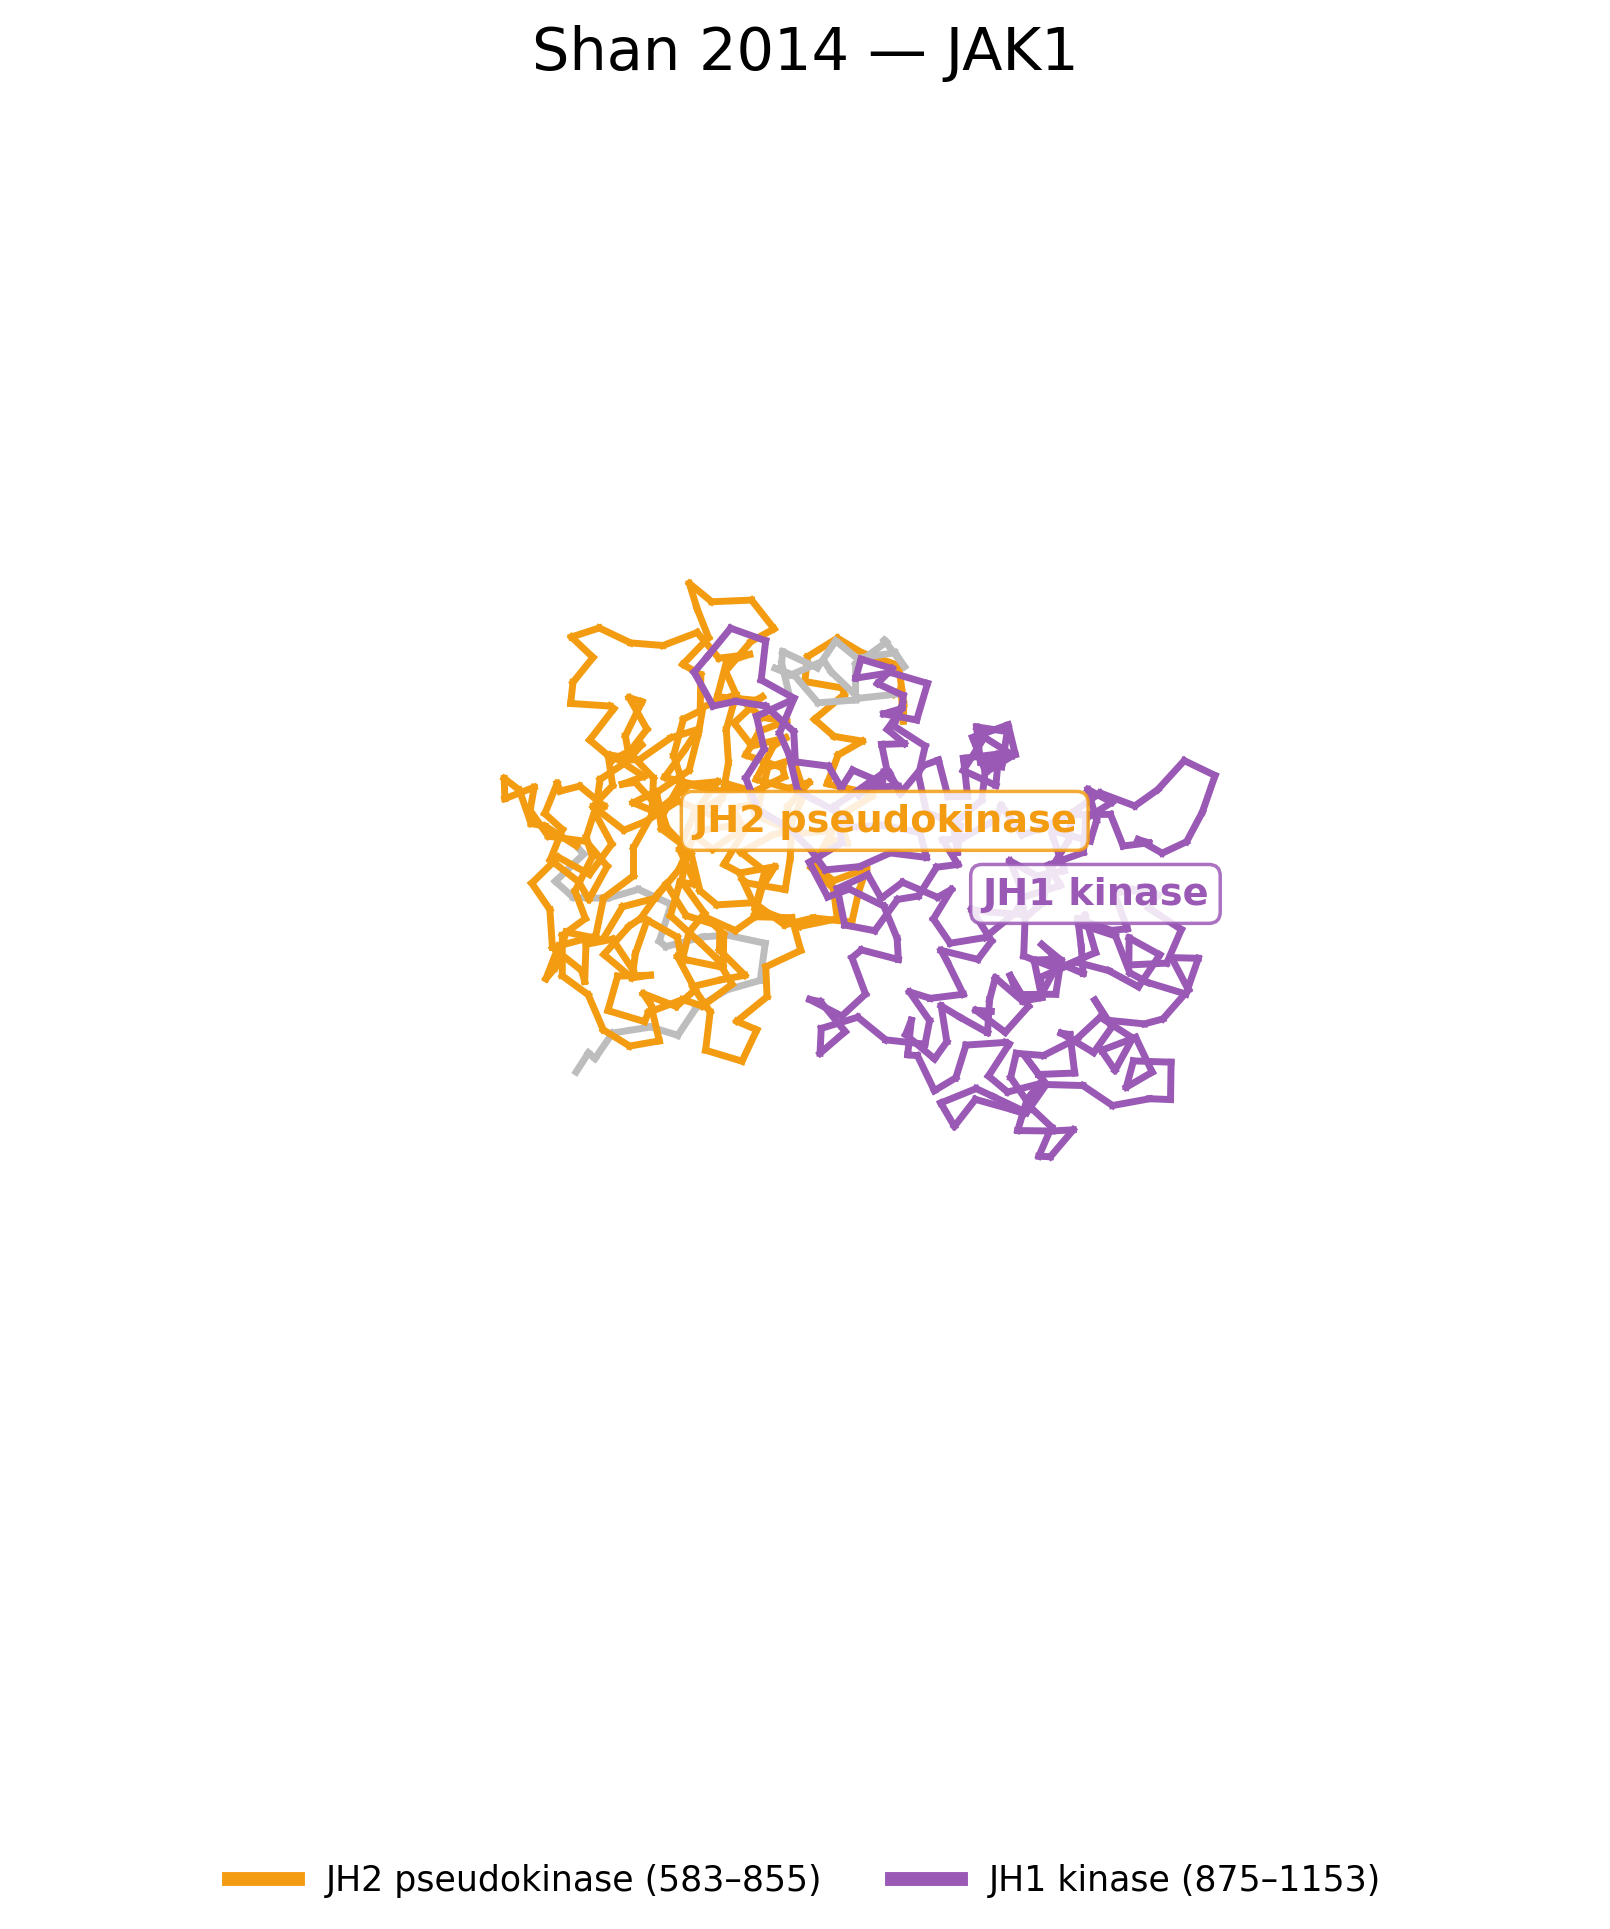

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
%pip install -q matplotlib

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display, Image


def save_model_png(name, dpi=250):
    model = models[name]
    mapping = model["mapping"]

    positions = sorted(mapping)
    xyz = np.array(
        [mapping[p]["CA"].coord for p in positions],
        dtype=float,
    )

    # Centre the structure for plotting.
    origin = xyz.mean(axis=0)
    xyz -= origin

    def domain_for_position(position):
        for domain in plot_domains:
            if domain["start"] <= position <= domain["end"]:
                return domain
        return None

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_proj_type("ortho")

    # Draw connected Cα segments; avoid bridging missing residues.
    for i in range(len(positions) - 1):
        if positions[i + 1] != positions[i] + 1:
            continue
        if np.linalg.norm(xyz[i + 1] - xyz[i]) > 5.0:
            continue

        domain = domain_for_position(positions[i])
        color = domain["color"] if domain else "#bdbdbd"

        ax.plot(
            xyz[i:i + 2, 0],
            xyz[i:i + 2, 1],
            xyz[i:i + 2, 2],
            color=color,
            linewidth=2.0,
        )

    legend_handles = []

    for domain in plot_domains:
        domain_positions = [
            p for p in positions
            if domain["start"] <= p <= domain["end"]
        ]
        if not domain_positions:
            continue

        center = centroid(mapping, domain_positions) - origin

        ax.text(
            *center,
            domain["name"],
            fontsize=11,
            color=domain["color"],
            fontweight="bold",
            bbox={
                "facecolor": "white",
                "edgecolor": domain["color"],
                "alpha": 0.85,
                "boxstyle": "round,pad=0.3",
            },
        )

        legend_handles.append(
            Line2D(
                [0], [0],
                color=domain["color"],
                linewidth=4,
                label=(
                    f"{domain['name']} "
                    f"({domain['start']}–{domain['end']})"
                ),
            )
        )

    # Equal spatial scale along all three axes.
    midpoint = (xyz.min(axis=0) + xyz.max(axis=0)) / 2
    half_width = max(np.ptp(xyz, axis=0).max() / 2, 1) * 1.12

    ax.set_xlim(midpoint[0] - half_width, midpoint[0] + half_width)
    ax.set_ylim(midpoint[1] - half_width, midpoint[1] + half_width)
    ax.set_zlim(midpoint[2] - half_width, midpoint[2] + half_width)
    ax.set_box_aspect((1, 1, 1))

    ax.view_init(elev=20, azim=45)
    ax.set_axis_off()
    ax.set_title(f"{name} — JAK1", fontsize=17, pad=15)

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=2,
        frameon=False,
        fontsize=10,
    )
    fig.subplots_adjust(bottom=0.12, top=0.90)

    png_path = OUTPUT_DIR / (
        name.replace(" ", "_") + "_domains.png"
    )
    fig.savefig(
        png_path,
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.close(fig)

    print(png_path)
    display(Image(filename=str(png_path)))
    return png_path


png_paths = [
    save_model_png(name)
    for name in MODEL_URLS
]

# Bundle all four PNGs for downloading from Colab.
import zipfile
from google.colab import files

zip_path = OUTPUT_DIR / "JAK1_four_models_PNG.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as archive:
    for path in png_paths:
        archive.write(path, arcname=path.name)

files.download(str(zip_path))